# PhishGuard Lite — URL Detection Pipeline (Complete Notebook)

**East West University — CSE400B Capstone Project**

This single notebook contains the entire URL detection pipeline:

1. **Feature Extractor** — convert any URL into 26 numeric features
2. **Data Loader** — load and balance 4 public phishing datasets
3. **Training** — XGBoost (supervised) + Isolation Forest (unsupervised) + TF-IDF
4. **Evaluation** — F1, AUC, FPR, Precision@top-5%
5. **Inference** — load saved models and score any URL with GREEN/YELLOW/RED

Run cells top-to-bottom. Training takes ~5 minutes.

> **Updated pipeline (v2).** Key fixes for real-world extension accuracy:
> 1. **Domain-disjoint split** (no host in both train & test) — stops the model memorizing domains.
> 2. **Tranco apex capped** — legit class is no longer dominated by path-less domains (fewer false positives on legit deep links).
> 3. **Anomaly range + alert thresholds auto-computed from data** and saved to `url_meta.pkl`.
>
> Re-run top-to-bottom. Reported metrics may look lower than before — that is the removed leakage, and it matches how the extension actually behaves.

In [1]:
import sys
print(sys.executable)

import numpy
print("NumPy OK:", numpy.__version__)

c:\Users\Pc\AppData\Local\Programs\Python\Python311\python.exe
NumPy OK: 1.26.4


## 1. Setup and Imports

In [2]:
# Install required libraries (uncomment if running for the first time)
# !pip install pandas numpy scikit-learn xgboost joblib scipy

import os
import re
import math
import warnings
import numpy as np

import pandas as pd
import joblib

import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score
)
from scipy.sparse import hstack, csr_matrix
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
import pandas as pd
import os

TRANCO_FILE = r"E:\Project Demo\Research\data\Top Sites.csv"

TRANCO = pd.read_csv(
    TRANCO_FILE,
    header=None,
    names=["rank", "domain"],
    nrows=100000
)

print(TRANCO.head())

domains = []

for domain in TRANCO["domain"].dropna():

    brand = str(domain).split(".")[0].lower()

    if len(brand) >= 3:
        domains.append(brand)

# remove duplicates while preserving order
domains = list(dict.fromkeys(domains))

TOP_BRANDS = domains[:10000]
ALL_BRANDS = domains[:20000]

print("TOP_BRANDS:", len(TOP_BRANDS))
print("ALL_BRANDS:", len(ALL_BRANDS))

print("Sample:", TOP_BRANDS[:20])

   rank            domain
0     1        google.com
1     2  gtld-servers.net
2     3    cloudflare.com
3     4       gstatic.com
4     5      facebook.com
TOP_BRANDS: 10000
ALL_BRANDS: 20000
Sample: ['google', 'gtld-servers', 'cloudflare', 'gstatic', 'facebook', 'microsoft', 'googleapis', 'youtube', 'amazonaws', 'apple', 'instagram', 'mail', 'ezviz7', 'fbcdn', 'akamai', 'dzen', 'twitter', 'linkedin', 'googletagmanager', 'googlevideo']


## 2. Configuration

Set the paths to your data and where models will be saved.

**Important:** Update `DATA_DIR` to point to your CSV files.

In [4]:
# Paths
DATA_DIR = r"E:\Project Demo\Research\data"        # Folder containing the CSV datasets
MODELS_DIR = "models"                      # Folder where trained models will be saved


DATASETS = [
    "phishing_site_urls.csv",
    "malicious_phish.csv",
    "PhiUSIIL_Phishing_URL_Dataset.csv",
    "Malicious URL v3.csv",
    
    
]
TRANCO_FILE = "tranco_43Z8X.csv"


TRANCO_LIMIT = 100000

SAMPLES_PER_CLASS = 150000
TFIDF_FEATURES = 3000
RANDOM_STATE = 42

# Decision fusion weights
W_SUPERVISED = 0.70
W_ANOMALY = 0.30


ANOMALY_MIN = 0.40
ANOMALY_MAX = 0.70
RED_THRESHOLD = 0.65
YELLOW_THRESHOLD = 0.40


TARGET_FPR_RED = 0.03
TARGET_FPR_YELLOW = 0.12

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Models will be saved to: {os.path.abspath(MODELS_DIR)}")


Models will be saved to: e:\Project Demo\Research\models


## 3. URL Feature Extractor

Extracts **26 features** from any URL. These features capture lexical, structural, and entropy-based signals that distinguish phishing from legitimate URLs.

In [5]:
import math
from pyexpat import features
from urllib.parse import urlparse
from rapidfuzz.distance import Levenshtein
from rapidfuzz import fuzz
import re

IPV4_RE = re.compile(r"^\d{1,3}(\.\d{1,3}){3}$")

SPECIAL_CHARS = {"@", "?", "=", "&", "%"}

SUSPICIOUS_WORDS = [
    "login", "verify", "secure", "account", "bank", "update",
    "signin", "password", "confirm", "wallet",
    "crypto", "bonus", "free",
]

RISKY_TLDS = {"xyz", "top", "tk", "ml", "ga", "cf", "gq", "click", "work"}

SHORTENERS = {"bit.ly", "tinyurl.com", "t.co", "goo.gl", "ow.ly", "is.gd"}


def safe_parse_url(url):
    """Add http:// if protocol missing, so urlparse works correctly."""
    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.\-]*://", url):
        url = "http://" + url
    return urlparse(url)


def calculate_entropy(text):
    if not text:
        return 0.0
    prob = [text.count(c) / len(text) for c in set(text)]
    return -sum(p * math.log2(p) for p in prob)



HOMOGLYPHS = {
    "0": "o",
    "1": "l",
    "3": "e",
    "5": "s",
    "@": "a",
    "$": "s"
}
HOMOGRAPH_MAP = {
    "а": "a", 
    "е": "e",
    "о": "o",
    "р": "p",
    "с": "c",
    "у": "y",
    "х": "x",
    "і": "i",
    "ј": "j",
    "ӏ": "l",
}

def normalize_homoglyphs(text):
    text = text.lower()
    for fake, real in HOMOGLYPHS.items():
        text = text.replace(fake, real)
    return text


def normalize_homograph(text):

    normalized = ""

    for ch in text:
        normalized += HOMOGRAPH_MAP.get(ch, ch)

    return normalized

def get_closest_brand(domain):
    best_brand = ""
    min_dist = 999

    for brand in ALL_BRANDS:
        dist = Levenshtein.distance(domain, brand)

        if dist < min_dist:
            min_dist = dist
            best_brand = brand

    return best_brand, min_dist

def similarity_score(domain):

    max_score = 0

    for brand in ALL_BRANDS:
        score = fuzz.ratio(domain, brand)
        max_score = max(max_score, score)

    return max_score

def is_typosquat(domain):

    normalized = normalize_homograph(domain)
    normalized = normalize_homoglyphs(normalized)

    if normalized in TOP_BRANDS and domain != normalized:
        return 1

    return 0

def homograph_features(domain):

    count = 0

    for ch in domain:
        if ch in HOMOGRAPH_MAP:
            count += 1

    normalized = normalize_homograph(domain)
    normalized = normalize_homoglyphs(normalized)

    brand_match = 0

    if normalized in TOP_BRANDS:
        brand_match = 1

    return {
        "has_homograph": int(count > 0),
        "homograph_count": count,
        "normalized_brand_match": brand_match
    }
    

        
def brand_features(url):

    parsed = safe_parse_url(url)

    host = (parsed.hostname or "").lower()

    if host.startswith("www."):
        host = host[4:]

    domain = host.split(".")[0]

    normalized = normalize_homograph(domain)
    normalized = normalize_homoglyphs(normalized)

    closest_brand, distance = get_closest_brand(normalized)

    spoof_score = similarity_score(normalized)

    keyword_count = 0

    for brand in TOP_BRANDS:
        if brand in domain:

            if domain != brand:
                keyword_count += 1

    return {
        "brand_spoof_score": spoof_score,
        "closest_brand_distance": distance,
        "brand_keyword_count": keyword_count,
        "is_typosquat": is_typosquat(domain)
    }

def extract_features(url):
    """Return (values, names) for an input URL."""
    features = {}

    parsed = safe_parse_url(url)
    host = (parsed.hostname or "").lower()
    path = parsed.path or ""
    query = parsed.query or ""
    url_lower = url.lower()

    host_no_www = host[4:] if host.startswith("www.") else host
    domain_parts = host_no_www.split(".") if host_no_www else []
    

    has_ip = 1 if IPV4_RE.match(host) else 0

    # Length features
    features["url_length"] = len(url)
    features["host_length"] = len(host)
    features["path_length"] = len(path)
    features["query_length"] = len(query)

    # Character counts
    features["dot_count"] = url.count(".")
    features["hyphen_count"] = url.count("-")
    features["slash_count"] = url.count("/")
    features["digit_count"] = sum(c.isdigit() for c in url)
    features["special_char_count"] = sum(c in SPECIAL_CHARS for c in url)
    features["has_at_symbol"] = 1 if "@" in url else 0

    # Protocol
    features["has_https"] = 1 if parsed.scheme == "https" else 0
    features["https_in_path"] = 1 if "https" in path.lower() else 0

    # Subdomain
    if has_ip:
        features["subdomain_count"] = 0
    elif len(domain_parts) > 2:
        features["subdomain_count"] = len(domain_parts) - 2
    else:
        features["subdomain_count"] = 0

    # Host features
    features["host_digit_ratio"] = (
        sum(c.isdigit() for c in host) / len(host) if len(host) > 0 else 0.0
    )
    features["hyphen_in_host"] = 1 if "-" in host else 0
    features["has_ip"] = has_ip

    # Path features
    features["path_depth"] = path.count("/")
    cleaned_url = re.sub(r"^[a-zA-Z][a-zA-Z0-9+.\-]*://", "", url)
    features["double_slash_count"] = cleaned_url.count("//")
    tokens = re.split(r"[./?=&_\-:]", url)
    features["max_token_length"] = max((len(t) for t in tokens if t), default=0)

    # Suspicious words
    features["suspicious_word_count"] = sum(w in url_lower for w in SUSPICIOUS_WORDS)

    # TLD
    tld = "" if has_ip else (
        domain_parts[-1] if len(domain_parts) >= 2 else ""
    )

    features["risky_tld"] = 1 if tld in RISKY_TLDS else 0
    features["tld_in_path"] = 1 if (tld and tld in path.lower()) else 0

    # Shortener
    features["is_shortened"] = 1 if host in SHORTENERS else 0

    # Entropy
    features["host_entropy"] = calculate_entropy(host) if len(host) >= 12 else 0.0
    features["path_entropy"] = calculate_entropy(path) if len(path) >= 12 else 0.0

    # Brand Similarity Features
    features.update(
        brand_features(url)   
    )
    domain_only = host_no_www.split(".")[0]

    features.update(
    homograph_features(domain_only)
    )

    return list(features.values()), list(features.keys())

# Test it
test_url = "http://secure-login-bank.xyz/verify"
values, names = extract_features(test_url)
print(f"Test URL: {test_url}")
print(f"Number of features: {len(values)}")
for name, value in zip(names, values):
    print(f"  {name:25s} = {value}")

Test URL: http://secure-login-bank.xyz/verify
Number of features: 32
  url_length                = 35
  host_length               = 21
  path_length               = 7
  query_length              = 0
  dot_count                 = 1
  hyphen_count              = 2
  slash_count               = 3
  digit_count               = 0
  special_char_count        = 0
  has_at_symbol             = 0
  has_https                 = 0
  https_in_path             = 0
  subdomain_count           = 0
  host_digit_ratio          = 0.0
  hyphen_in_host            = 1
  has_ip                    = 0
  path_depth                = 1
  double_slash_count        = 0
  max_token_length          = 6
  suspicious_word_count     = 4
  risky_tld                 = 1
  tld_in_path               = 0
  is_shortened              = 0
  host_entropy              = 4.106603137064474
  path_entropy              = 0.0
  brand_spoof_score         = 62.06896551724138
  closest_brand_distance    = 8
  brand_keyword_count       =

Test parts

In [6]:
test_urls = [
    "https://paypal.com",
    "https://paypa1.com",
    "https://g00gle.com",
    "https://faceb00k.com",
    "https://amaz0n.com",
    "https://micr0soft.com"
]

for url in test_urls:

    values, names = extract_features(url)

    idx = names.index("is_typosquat")

    print(url, "=>", values[idx])

https://paypal.com => 0
https://paypa1.com => 1
https://g00gle.com => 1
https://faceb00k.com => 1
https://amaz0n.com => 1
https://micr0soft.com => 1


In [7]:
test_url = "https://kFc1.com/login"

values, names = extract_features(test_url)

for n, v in zip(names, values):
    if "brand" in n:
        print(n, "=", v)

brand_spoof_score = 85.71428571428572
closest_brand_distance = 1
brand_keyword_count = 0
normalized_brand_match = 0


In [8]:
test_url = "https://аррӏе.com"

values, names = extract_features(test_url)

for n, v in zip(names, values):
    if "homograph" in n or "brand_match" in n:
        print(n, "=", v)

has_homograph = 1
homograph_count = 5
normalized_brand_match = 1


In [9]:
test_url = "https://secure-MMac-login.xyz"
values, names = extract_features(test_url)

for n, v in zip(names, values):
    if "brand" in n:
        print(n, "=", v)

brand_spoof_score = 60.60606060606061
closest_brand_distance = 9
brand_keyword_count = 4
normalized_brand_match = 0


## 4. Helper Functions

In [10]:
def normalize_url(url):
    """Strip protocol so training and inference data match."""
    url = str(url).strip()
    for prefix in ("https://", "http://", "ftp://"):
        if url.lower().startswith(prefix):
            return url[len(prefix):]
    return url


def normalize_label(label):
    """Map any label format to 0 (legit) or 1 (phishing)."""
    label = str(label).lower().strip()
    phishing = {"bad", "phishing", "malicious", "malware", "defacement", "spam", "smish", "1"}
    legit = {"good", "benign", "legitimate", "safe", "normal", "0"}
    if label in phishing:
        return 1
    if label in legit:
        return 0
    return None


def detect_columns(df):
    """Auto-detect URL and label columns across different dataset formats."""
    url_cands = ["url", "URL", "domain"]
    lbl_cands = ["label", "Label", "type", "status", "result"]
    url_col = next((c for c in url_cands if c in df.columns), None)
    lbl_col = next((c for c in lbl_cands if c in df.columns), None)
    if url_col is None or lbl_col is None:
        raise Exception(f"Cannot detect columns in {list(df.columns)}")
    return url_col, lbl_col


print("Helper functions defined.")

Helper functions defined.


registered_host()

In [11]:
import re

def registered_host(url):
    u = str(url)

    u = re.sub(
        r"^[a-zA-Z][a-zA-Z0-9+.\-]*://",
        "",
        u
    )

    u = u.split("/")[0]
    u = u.split("?")[0]
    u = u.split("#")[0]

    u = u.split("@")[-1]
    u = u.split(":")[0]

    u = u.lower()

    if u.startswith("www."):
        u = u[4:]

    return u

In [12]:
print(registered_host("https://www.google.com/test"))

google.com


## 5. Load and Combine Datasets


In [13]:
def load_all_datasets():
    print("=" * 60)
    print("LOADING DATASETS")
    print("=" * 60)

    parts = []

    for fname in DATASETS:
        if not fname:
            continue

        path = os.path.join(DATA_DIR, fname)

        if not os.path.exists(path):
            print(f"  SKIP (not found): {path}")
            continue

        try:
            df = pd.read_csv(path, on_bad_lines="skip")
        except Exception as e:
            print(f"  ERROR: {e}")
            continue

        url_col, lbl_col = detect_columns(df)

        df = df[[url_col, lbl_col]].copy()
        df.columns = ["url", "label"]

        df = df.dropna()

        # PhiUSIIL uses inverted labels
        if fname == "PhiUSIIL_Phishing_URL_Dataset.csv":
            df["label"] = 1 - df["label"].astype(int)
        else:
            df["label"] = df["label"].apply(normalize_label)
            df = df.dropna()

        df["label"] = df["label"].astype(int)
        df["url"] = df["url"].apply(normalize_url)

        print(
            f"  {fname}: {len(df):,}   "
            f"{df['label'].value_counts().to_dict()}"
        )

        parts.append(df)

    # --------------------------------------------------
    # TRANGO LEGITIMATE URLS
    # --------------------------------------------------

    tranco_path = os.path.join(DATA_DIR, TRANCO_FILE)

    if os.path.exists(tranco_path):

        df_t = pd.read_csv(
            tranco_path,
            header=None,
            names=["rank", "domain"],
            nrows=TRANCO_LIMIT
        )

        df_t["url"] = df_t["domain"].astype(str)
        df_t["label"] = 0

        df_t = df_t[["url", "label"]].dropna()

        df_t_slash = df_t.sample(
            frac=0.25,
            random_state=RANDOM_STATE
        ).copy()

        df_t_slash["url"] = df_t_slash["url"] + "/"

        # Real-world legit traffic is overwhelmingly "www.<domain>", but the
        # apex-only Tranco rows above never include it. Without these, the
        # model learns "no www." == legit and flags real www. sites as risky.

        df_t_www = df_t.sample(
            frac=0.5,
            random_state=RANDOM_STATE
        ).copy()
        df_t_www["url"] = "www." + df_t_www["url"]

        df_t_www_slash = df_t_www.sample(
            frac=0.25,
            random_state=RANDOM_STATE
        ).copy()
        df_t_www_slash["url"] = df_t_www_slash["url"] + "/"

       
        top_brand_domains = df_t["url"].head(2000)  

        boost_variants = []
        paths = ["", "/", "/home", "/about", "/index.html", "/en", "/login", "/search"]
        for d in top_brand_domains:
            for p in paths:
                boost_variants.append(d + p)
                boost_variants.append("www." + d + p)

        df_boost = pd.DataFrame({"url": boost_variants, "label": 0})

        print(f"  top-brand boost: {len(df_boost):,} distinct rows")

        print(
            f"  tranco apex: {len(df_t):,}   "
            f"tranco apex+slash: {len(df_t_slash):,}   "
            f"tranco www: {len(df_t_www):,}   "
            f"tranco www+slash: {len(df_t_www_slash):,}"
        )

        parts.append(df_t)
        parts.append(df_t_slash)
        parts.append(df_t_www)
        parts.append(df_t_www_slash)
        parts.append(df_boost)


    # --------------------------------------------------
    # MERGE
    # --------------------------------------------------

    df_all = pd.concat(parts, ignore_index=True)

    print(f"\nBefore Cleanup: {len(df_all):,}")

    # --------------------------------------------------
    # BASIC CLEANUP
    # --------------------------------------------------

    df_all = df_all.dropna(subset=["url"])

    df_all["url"] = (
        df_all["url"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    df_all = df_all[df_all["url"] != ""]

    df_all = df_all[
        df_all["url"].str.len() > 3
    ]

    print(
        f"After URL Cleanup: {len(df_all):,}"
    )

    # --------------------------------------------------
    # REMOVE CONFLICTING LABELS
    # --------------------------------------------------

    conflicts = (
        df_all.groupby("url")["label"]
        .nunique()
    )

    conflicting_urls = conflicts[
        conflicts > 1
    ].index

    print(
        f"Conflicting URLs removed: "
        f"{len(conflicting_urls):,}"
    )

    df_all = df_all[
        ~df_all["url"].isin(conflicting_urls)
    ]

    print(
        f"After Conflict Removal: "
        f"{len(df_all):,}"
    )

    # --------------------------------------------------
    # REMOVE DUPLICATES
    # --------------------------------------------------

    before_dup = len(df_all)

    df_all = df_all.drop_duplicates(
        subset=["url"]
    )

    removed_dup = before_dup - len(df_all)

    print(
        f"Duplicate URLs removed: "
        f"{removed_dup:,}"
    )

    # --------------------------------------------------
    # HOST EXTRACTION
    # --------------------------------------------------

    df_all["host"] = df_all["url"].apply(
        registered_host
    )

    df_all = df_all[
        df_all["host"].str.len() > 0
    ]

    # --------------------------------------------------
    # FINAL STATS
    # --------------------------------------------------

    print("\nFinal Dataset Distribution:")
    print(df_all["label"].value_counts())

    print(
        f"\nCombined Dataset Size: "
        f"{len(df_all):,}"
    )

    print(
        f"Unique Hosts: "
        f"{df_all['host'].nunique():,}"
    )

    return df_all


df_all = load_all_datasets()

LOADING DATASETS
  phishing_site_urls.csv: 549,346   {0: 392924, 1: 156422}
  malicious_phish.csv: 651,191   {0: 428103, 1: 223088}
  PhiUSIIL_Phishing_URL_Dataset.csv: 235,795   {0: 134850, 1: 100945}
  Malicious URL v3.csv: 49,750   {0: 36419, 1: 13331}
  top-brand boost: 32,000 distinct rows
  tranco apex: 100,000   tranco apex+slash: 25,000   tranco www: 50,000   tranco www+slash: 12,500

Before Cleanup: 1,705,582
After URL Cleanup: 1,705,574
Conflicting URLs removed: 96,185
After Conflict Removal: 1,508,650
Duplicate URLs removed: 458,532

Final Dataset Distribution:
label
0    724748
1    325369
Name: count, dtype: int64

Combined Dataset Size: 1,050,117
Unique Hosts: 481,515


## 6. Balance the Dataset

In [14]:
def balance(df, n_per_class):
    phish = df[df["label"] == 1]
    legit = df[df["label"] == 0]
    n = min(len(phish), len(legit), n_per_class)
    print(f"Sampling {n:,} URLs per class.")
    out = pd.concat([
        phish.sample(n=n, random_state=RANDOM_STATE),
        legit.sample(n=n, random_state=RANDOM_STATE),
    ], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    return out


df = balance(df_all, SAMPLES_PER_CLASS)   # keeps url, label, host columns
print(f"Final balanced dataset: {len(df):,}")
print(f"Class balance: {df['label'].value_counts().to_dict()}")


Sampling 150,000 URLs per class.
Final balanced dataset: 300,000
Class balance: {1: 150000, 0: 150000}


## 7. Train/Test Split

Split FIRST, then fit TF-IDF only on training data to avoid data leakage.

In [15]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(df, groups=df["host"]))
df_train = df.iloc[tr_idx].reset_index(drop=True)
df_test = df.iloc[te_idx].reset_index(drop=True)

overlap = set(df_train["host"]) & set(df_test["host"])
print(f"Train: {len(df_train):,}    Test: {len(df_test):,}")
print(f"Hosts -> train: {df_train['host'].nunique():,}  test: {df_test['host'].nunique():,}")
print(f"Host overlap (must be 0): {len(overlap)}")
print(f"Train balance: {df_train['label'].value_counts().to_dict()}")
print(f"Test  balance: {df_test['label'].value_counts().to_dict()}")


Train: 237,526    Test: 62,474
Hosts -> train: 137,291  test: 34,323
Host overlap (must be 0): 0
Train balance: {0: 119164, 1: 118362}
Test  balance: {1: 31638, 0: 30836}


## 8. Extract Handcrafted Features

In [16]:
def featurize_urls(urls, labels, feature_names_ref=None):
    """Extract handcrafted features, drop failures, keep URLs aligned with labels."""
    rows, lbls, valid_urls = [], [], []
    feature_names = feature_names_ref
    for url, lbl in zip(urls, labels):
        try:
            vals, names = extract_features(url)
            if feature_names is None:
                feature_names = names
            if len(vals) == len(feature_names):
                rows.append(vals)
                lbls.append(lbl)
                valid_urls.append(url)
        except Exception:
            continue
    X = pd.DataFrame(rows, columns=feature_names)
    y = pd.Series(lbls).reset_index(drop=True)
    return X, y, valid_urls, feature_names


print("Extracting handcrafted features...")
X_train_h, y_train, train_urls, feat_names = featurize_urls(df_train["url"], df_train["label"])
X_test_h, y_test, test_urls, _ = featurize_urls(df_test["url"], df_test["label"], feat_names)
print(f"Train handcrafted: {X_train_h.shape}")
print(f"Test handcrafted:  {X_test_h.shape}")

Extracting handcrafted features...
Train handcrafted: (237525, 32)
Test handcrafted:  (62474, 32)


## 9. TF-IDF Character N-grams

Adds 2000 character-level features (3-5 character windows) that let the model learn patterns like `login`, `verif`, `secur`, `.tk/` automatically.

In [17]:
print("Fitting TF-IDF on training URLs only (no data leakage)...")
vec = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=TFIDF_FEATURES,
    min_df=5,
)
X_train_t = vec.fit_transform(train_urls)
X_test_t = vec.transform(test_urls)
print(f"Train TF-IDF: {X_train_t.shape}")
print(f"Test TF-IDF:  {X_test_t.shape}")

# Combine handcrafted + TF-IDF
X_train = hstack([csr_matrix(X_train_h.values), X_train_t])
X_test  = hstack([csr_matrix(X_test_h.values),  X_test_t])
print(f"\nCombined Train: {X_train.shape}")
print(f"Combined Test:  {X_test.shape}")

Fitting TF-IDF on training URLs only (no data leakage)...
Train TF-IDF: (237525, 3000)
Test TF-IDF:  (62474, 3000)

Combined Train: (237525, 3032)
Combined Test:  (62474, 3032)


## 10. Train XGBoost (Supervised Classifier)

In [18]:
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=["legit", "phish"], digits=4))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) if (fp + tn) else 0

print(f"Confusion Matrix:\n{cm}")
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}    (target >= 0.95)")
print(f"FPR: {fpr:.4f}    (target <= 0.05)")
print(f"F1:  {f1_score(y_test, y_pred):.4f}    (target >= 0.92)")

Training XGBoost...

Accuracy: 0.9132
              precision    recall  f1-score   support

       legit     0.8773    0.9582    0.9160     30836
       phish     0.9553    0.8694    0.9103     31638

    accuracy                         0.9132     62474
   macro avg     0.9163    0.9138    0.9131     62474
weighted avg     0.9168    0.9132    0.9131     62474

Confusion Matrix:
[[29548  1288]
 [ 4133 27505]]
AUC: 0.9703    (target >= 0.95)
FPR: 0.0418    (target <= 0.05)
F1:  0.9103    (target >= 0.92)


In [19]:
importances = xgb_model.feature_importances_
n_struct = len(feat_names)  # structural feature count
struct_imp = importances[:n_struct]
tfidf_imp_sum = importances[n_struct:].sum()

print("Structural feature importance sum:", struct_imp.sum())
print("TF-IDF importance sum:", tfidf_imp_sum)
print()
for name, imp in sorted(zip(feat_names, struct_imp), key=lambda x: -x[1])[:10]:
    print(f"  {name:25s} {imp:.4f}")

Structural feature importance sum: 0.055262115
TF-IDF importance sum: 0.9447379

  dot_count                 0.0115
  risky_tld                 0.0069
  is_shortened              0.0048
  subdomain_count           0.0047
  suspicious_word_count     0.0039
  host_digit_ratio          0.0031
  brand_spoof_score         0.0030
  has_ip                    0.0025
  hyphen_in_host            0.0022
  path_length               0.0017


## 11. Confusion Matrix Visualization — XGBoost

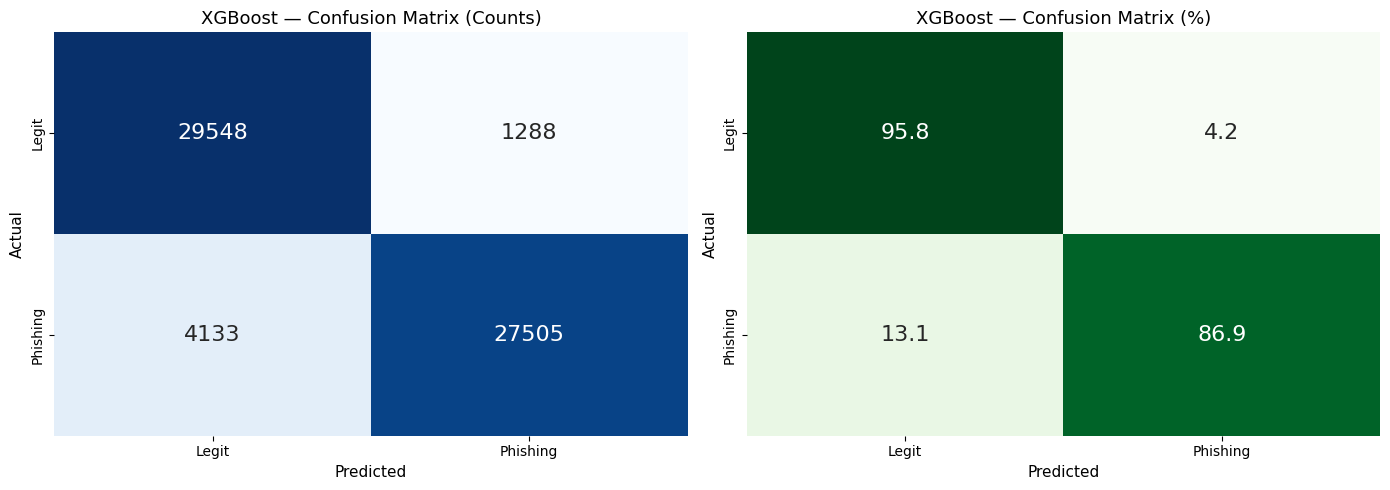

Saved: xgboost_confusion_matrix.png


In [20]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw counts
cm_xgb = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legit', 'Phishing'],
    yticklabels=['Legit', 'Phishing'],
    ax=ax[0], cbar=False, annot_kws={'size': 16}
)
ax[0].set_title('XGBoost — Confusion Matrix (Counts)', fontsize=13)
ax[0].set_xlabel('Predicted', fontsize=11)
ax[0].set_ylabel('Actual', fontsize=11)

# Right: Percentages
cm_pct = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Greens',
    xticklabels=['Legit', 'Phishing'],
    yticklabels=['Legit', 'Phishing'],
    ax=ax[1], cbar=False, annot_kws={'size': 16}
)
ax[1].set_title('XGBoost — Confusion Matrix (%)', fontsize=13)
ax[1].set_xlabel('Predicted', fontsize=11)
ax[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('xgboost_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgboost_confusion_matrix.png")

In [21]:
importances = xgb_model.feature_importances_
n_struct = len(feat_names)  # structural feature count
struct_imp = importances[:n_struct]
tfidf_imp_sum = importances[n_struct:].sum()

print("Structural feature importance sum:", struct_imp.sum())
print("TF-IDF importance sum:", tfidf_imp_sum)
print()
for name, imp in sorted(zip(feat_names, struct_imp), key=lambda x: -x[1])[:10]:
    print(f"  {name:25s} {imp:.4f}")

Structural feature importance sum: 0.055262115
TF-IDF importance sum: 0.9447379

  dot_count                 0.0115
  risky_tld                 0.0069
  is_shortened              0.0048
  subdomain_count           0.0047
  suspicious_word_count     0.0039
  host_digit_ratio          0.0031
  brand_spoof_score         0.0030
  has_ip                    0.0025
  hyphen_in_host            0.0022
  path_length               0.0017


## 11. Train Isolation Forest (Unsupervised Anomaly Detector)

Trained only on **legitimate URLs**. Flags anomalies for zero-day phishing detection.

In [22]:
print("Training Isolation Forest on legitimate URLs only...")
X_legit = X_train_h[y_train == 0]
print(f"Fitting on {len(X_legit):,} legitimate URLs.")

iso_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
iso_model.fit(X_legit)

scores = -iso_model.score_samples(X_test_h)          # test anomaly (higher = more anomalous)
preds = (iso_model.predict(X_test_h) == -1).astype(int)
cm = confusion_matrix(y_test, preds)

print(f"\nConfusion Matrix:\n{cm}")
print(f"AUC: {roc_auc_score(y_test, scores):.4f}    (target >= 0.85)")
print(f"F1:  {f1_score(y_test, preds):.4f}")

k = max(1, int(0.05 * len(scores)))
top_k = np.argsort(scores)[-k:]
p_at_k = y_test.iloc[top_k].sum() / k
print(f"Precision@top-5% anomalies: {p_at_k:.4f}    <-- key result")

# --- AUTO-CALIBRATE anomaly normalization from TRAIN data (replaces hardcoded) ---
train_anom_raw = -iso_model.score_samples(X_train_h)
ANOMALY_MIN = float(np.percentile(train_anom_raw, 5))
ANOMALY_MAX = float(np.percentile(train_anom_raw, 99))
if ANOMALY_MAX <= ANOMALY_MIN:
    ANOMALY_MAX = ANOMALY_MIN + 1e-6
print(f"\nAuto anomaly range -> MIN={ANOMALY_MIN:.4f}  MAX={ANOMALY_MAX:.4f}")


Training Isolation Forest on legitimate URLs only...
Fitting on 119,164 legitimate URLs.

Confusion Matrix:
[[27959  2877]
 [19064 12574]]
AUC: 0.7230    (target >= 0.85)
F1:  0.5341
Precision@top-5% anomalies: 0.9174    <-- key result

Auto anomaly range -> MIN=0.3561  MAX=0.6777


## 12. Confusion Matrix Visualization — Isolation Forest

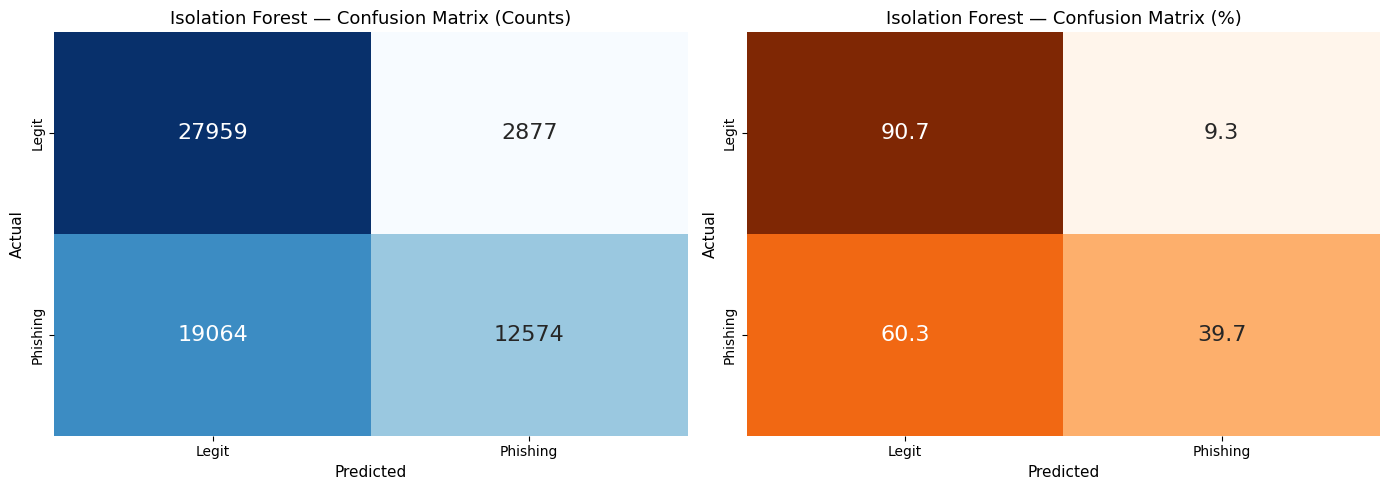

Saved: isolation_forest_confusion_matrix.png


In [23]:

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

cm_iso = confusion_matrix(y_test, preds)
sns.heatmap(
    cm_iso, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legit', 'Phishing'],
    yticklabels=['Legit', 'Phishing'],
    ax=ax[0], cbar=False, annot_kws={'size': 16}
)
ax[0].set_title('Isolation Forest — Confusion Matrix (Counts)', fontsize=13)
ax[0].set_xlabel('Predicted', fontsize=11)
ax[0].set_ylabel('Actual', fontsize=11)

cm_pct = cm_iso.astype('float') / cm_iso.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Oranges',
    xticklabels=['Legit', 'Phishing'],
    yticklabels=['Legit', 'Phishing'],
    ax=ax[1], cbar=False, annot_kws={'size': 16}
)
ax[1].set_title('Isolation Forest — Confusion Matrix (%)', fontsize=13)
ax[1].set_xlabel('Predicted', fontsize=11)
ax[1].set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.savefig('isolation_forest_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: isolation_forest_confusion_matrix.png")

In [24]:
## ROC Curves — XGBoost vs Isolation Forest

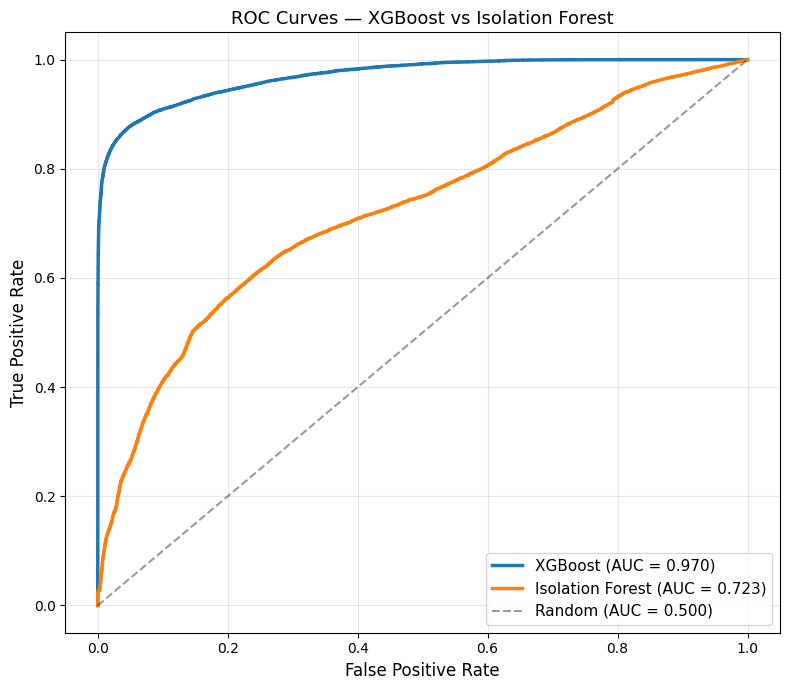

Saved: roc_curves.png


In [25]:

from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 7))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)
ax.plot(fpr_xgb, tpr_xgb,
        label=f'XGBoost (AUC = {auc_xgb:.3f})',
        color='#1f77b4', linewidth=2.5)

# Isolation Forest ROC
fpr_iso, tpr_iso, _ = roc_curve(y_test, scores)
auc_iso = auc(fpr_iso, tpr_iso)
ax.plot(fpr_iso, tpr_iso,
        label=f'Isolation Forest (AUC = {auc_iso:.3f})',
        color='#ff7f0e', linewidth=2.5)

# Random baseline (diagonal)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — XGBoost vs Isolation Forest', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curves.png")

## 11b. Data-driven alert thresholds

In [26]:

from sklearn.metrics import roc_curve

test_anom = np.clip((scores - ANOMALY_MIN) / (ANOMALY_MAX - ANOMALY_MIN), 0.0, 1.0)
fused_test = W_SUPERVISED * np.asarray(y_proba) + W_ANOMALY * test_anom

fpr_f, tpr_f, thr_f = roc_curve(y_test, fused_test)

def threshold_at_fpr(target_fpr):
    idx = np.searchsorted(fpr_f, target_fpr, side="right") - 1
    idx = max(0, min(idx, len(thr_f) - 1))
    return float(thr_f[idx]), float(tpr_f[idx]), float(fpr_f[idx])

RED_THRESHOLD, tpr_r, fpr_r = threshold_at_fpr(TARGET_FPR_RED)
YELLOW_THRESHOLD, tpr_y, fpr_y = threshold_at_fpr(TARGET_FPR_YELLOW)

# Guard: keep YELLOW strictly below RED
if YELLOW_THRESHOLD >= RED_THRESHOLD:
    YELLOW_THRESHOLD = RED_THRESHOLD * 0.6

print("Fused-score alert thresholds (chosen from data):")
print(f"  RED    >= {RED_THRESHOLD:.3f}   catches {tpr_r*100:5.1f}% of phishing  at {fpr_r*100:4.1f}% false alarms")
print(f"  YELLOW >= {YELLOW_THRESHOLD:.3f}   catches {tpr_y*100:5.1f}% of phishing  at {fpr_y*100:4.1f}% false alarms")

# Apply and report the resulting 3-way behaviour on the held-out test set
def to_alert(s):
    return np.where(s >= RED_THRESHOLD, "RED", np.where(s >= YELLOW_THRESHOLD, "YELLOW", "GREEN"))

alerts = to_alert(fused_test)
caught = ((alerts != "GREEN") & (y_test.values == 1)).sum()
total_phish = (y_test.values == 1).sum()
false_alarm = ((alerts != "GREEN") & (y_test.values == 0)).sum()
total_legit = (y_test.values == 0).sum()
print(f"\nPhishing flagged (RED or YELLOW): {caught}/{total_phish}  ({caught/total_phish*100:.1f}%)")
print(f"Legit wrongly flagged:           {false_alarm}/{total_legit}  ({false_alarm/total_legit*100:.1f}%)")


Fused-score alert thresholds (chosen from data):
  RED    >= 0.477   catches  84.9% of phishing  at  3.0% false alarms
  YELLOW >= 0.269   catches  91.1% of phishing  at 12.0% false alarms

Phishing flagged (RED or YELLOW): 28828/31638  (91.1%)
Legit wrongly flagged:           3693/30836  (12.0%)


In [27]:

rng = np.random.default_rng(RANDOM_STATE)
legit_idx = np.where(y_test.values == 0)[0]
phish_idx = np.where(y_test.values == 1)[0]

# simulate ~2% phishing prevalence
n_phish = len(phish_idx)
n_legit_needed = int(n_phish * 49)               # 1 : 49  -> ~2%
n_legit_needed = min(n_legit_needed, len(legit_idx))
sample_idx = np.concatenate([phish_idx, rng.choice(legit_idx, n_legit_needed, replace=False)])

s_rw = fused_test[sample_idx]
y_rw = y_test.values[sample_idx]
a_rw = to_alert(s_rw)

red_mask = a_rw == "RED"
flagged_mask = a_rw != "GREEN"
red_precision = (y_rw[red_mask] == 1).mean() if red_mask.sum() else float("nan")
flag_precision = (y_rw[flagged_mask] == 1).mean() if flagged_mask.sum() else float("nan")
recall = ((a_rw != "GREEN") & (y_rw == 1)).sum() / max(1, (y_rw == 1).sum())
print(f"At ~2% real-world prevalence:")
print(f"  RED precision    : {red_precision*100:5.1f}%   (a RED alert is real this often)")
print(f"  Flagged precision: {flag_precision*100:5.1f}%")
print(f"  Phishing recall  : {recall*100:5.1f}%")


At ~2% real-world prevalence:
  RED precision    :  96.7%   (a RED alert is real this often)
  Flagged precision:  88.6%
  Phishing recall  :  91.1%


## 12. Save Trained Models

In [28]:
joblib.dump(xgb_model,  os.path.join(MODELS_DIR, "xgboost_url_model.pkl"))
joblib.dump(iso_model,  os.path.join(MODELS_DIR, "isolation_forest_url_model.pkl"))
joblib.dump(vec,        os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(feat_names, os.path.join(MODELS_DIR, "url_feature_names.pkl"))

# Calibration metadata so the API/extension uses the SAME data-driven values
url_meta = {
    "feature_names":    list(feat_names),
    "anomaly_min":      float(ANOMALY_MIN),
    "anomaly_max":      float(ANOMALY_MAX),
    "red_threshold":    float(RED_THRESHOLD),
    "yellow_threshold": float(YELLOW_THRESHOLD),
    "w_supervised":     float(W_SUPERVISED),
    "w_anomaly":        float(W_ANOMALY),
}
joblib.dump(url_meta, os.path.join(MODELS_DIR, "url_meta.pkl"))

print("MODELS SAVED:")
for name in ["xgboost_url_model.pkl", "isolation_forest_url_model.pkl",
             "tfidf_vectorizer.pkl", "url_feature_names.pkl", "url_meta.pkl"]:
    path = os.path.join(MODELS_DIR, name)
    size_mb = os.path.getsize(path) / 1024 / 1024
    print(f"  {name:35s}  {size_mb:.3f} MB")
print(f"\nCalibration: {url_meta}")


MODELS SAVED:
  xgboost_url_model.pkl                1.517 MB
  isolation_forest_url_model.pkl       1.777 MB
  tfidf_vectorizer.pkl                 20.547 MB
  url_feature_names.pkl                0.001 MB
  url_meta.pkl                         0.001 MB

Calibration: {'feature_names': ['url_length', 'host_length', 'path_length', 'query_length', 'dot_count', 'hyphen_count', 'slash_count', 'digit_count', 'special_char_count', 'has_at_symbol', 'has_https', 'https_in_path', 'subdomain_count', 'host_digit_ratio', 'hyphen_in_host', 'has_ip', 'path_depth', 'double_slash_count', 'max_token_length', 'suspicious_word_count', 'risky_tld', 'tld_in_path', 'is_shortened', 'host_entropy', 'path_entropy', 'brand_spoof_score', 'closest_brand_distance', 'brand_keyword_count', 'is_typosquat', 'has_homograph', 'homograph_count', 'normalized_brand_match'], 'anomaly_min': 0.35607987635678034, 'anomaly_max': 0.6776841741277485, 'red_threshold': 0.47665384722182425, 'yellow_threshold': 0.26908473233758634, '

## 13. URL Scorer (Inference)

Combines the supervised XGBoost score and unsupervised Isolation Forest score using the Decision Fusion Layer (Algorithm 1 from your capstone report).

In [29]:
class URLScorer:
    """Load trained models + calibration and score any URL with GREEN/YELLOW/RED."""

    def __init__(self, models_dir=MODELS_DIR):
        self.xgb   = joblib.load(os.path.join(models_dir, "xgboost_url_model.pkl"))
        self.iso   = joblib.load(os.path.join(models_dir, "isolation_forest_url_model.pkl"))
        self.tfidf = joblib.load(os.path.join(models_dir, "tfidf_vectorizer.pkl"))
        try:
            meta = joblib.load(os.path.join(models_dir, "url_meta.pkl"))
        except Exception:
            meta = {}
        self.feature_names = meta.get("feature_names",
                                      joblib.load(os.path.join(models_dir, "url_feature_names.pkl")))
        self.n_features = len(self.feature_names)
        self.amin = meta.get("anomaly_min", ANOMALY_MIN)
        self.amax = meta.get("anomaly_max", ANOMALY_MAX)
        self.red  = meta.get("red_threshold", RED_THRESHOLD)
        self.yellow = meta.get("yellow_threshold", YELLOW_THRESHOLD)
        self.ws = meta.get("w_supervised", W_SUPERVISED)
        self.wa = meta.get("w_anomaly", W_ANOMALY)
        print(f"Loaded. Features: {self.n_features}, TF-IDF: {len(self.tfidf.vocabulary_)}, "
              f"RED>={self.red:.3f}, YELLOW>={self.yellow:.3f}")

    def _normalize_url(self, url):
        url = str(url).strip()
        for prefix in ("https://", "http://", "ftp://"):
            if url.lower().startswith(prefix):
                return url[len(prefix):]
        return url

    def _normalize_anomaly(self, raw):
        return float(np.clip((raw - self.amin) / (self.amax - self.amin), 0.0, 1.0))

    def _alert_level(self, fused):
        if fused >= self.red:
            return "RED"
        if fused >= self.yellow:
            return "YELLOW"
        return "GREEN"

    def score(self, url):
        original_url = url
        url = self._normalize_url(url)
        try:
            values, _ = extract_features(url)
        except Exception as e:
            return {"url": original_url, "error": str(e),
                    "alert_level": "YELLOW", "fused_score": 0.5}
        if len(values) != self.n_features:
            return {"url": original_url, "error": "feature mismatch",
                    "alert_level": "YELLOW", "fused_score": 0.5}

        h_arr = np.array(values, dtype=np.float32).reshape(1, -1)
        t_arr = self.tfidf.transform([url])
        X_combined = hstack([csr_matrix(h_arr), t_arr])

        s_url = float(self.xgb.predict_proba(X_combined)[0, 1])
        a_raw = float(-self.iso.score_samples(h_arr)[0])
        a_url = self._normalize_anomaly(a_raw)
        fused = self.ws * s_url + self.wa * a_url

        return {
            "url": original_url,
            "supervised_score": round(s_url, 4),
            "anomaly_score": round(a_url, 4),
            "fused_score": round(fused, 4),
            "alert_level": self._alert_level(fused),
        }


scorer = URLScorer()


Loaded. Features: 32, TF-IDF: 3000, RED>=0.477, YELLOW>=0.269


## 14. Test the Scorer on Real URLs

In [30]:
test_urls = [
    "https://www.google.com/",
    "https://github.com/user/repo",
    "https://bkash.com/en/payment",
    "https://paypal.com/signin",
    "http://secure-login-bank.xyz/verify/account123",
    "http://paypal-secure-verify-login.tk/a8f3kj2lq9pdsk44z/",
    "http://192.168.1.5/login",
    "https://bit.ly/3xR9pZ",
    "http://www.amazon.com",
    "https://sophie-world.com/crafts",
    "https://sophie-world.com/crafts/how-make-fishbowl-christmas-ornament",
]

print(f"{'Alert':6s}  {'fused':>6s}  {'sup':>6s}  {'anom':>6s}    URL")
print("-" * 90)
for url in test_urls:
    r = scorer.score(url)
    print(f"{r['alert_level']:6s}  "
          f"{r['fused_score']:6.3f}  "
          f"{r['supervised_score']:6.3f}  "
          f"{r['anomaly_score']:6.3f}    "
          f"{url}")

Alert    fused     sup    anom    URL
------------------------------------------------------------------------------------------
GREEN    0.049   0.008   0.144    https://www.google.com/
GREEN    0.078   0.021   0.213    https://github.com/user/repo
GREEN    0.124   0.103   0.173    https://bkash.com/en/payment
YELLOW   0.275   0.230   0.380    https://paypal.com/signin
RED      0.899   1.000   0.663    http://secure-login-bank.xyz/verify/account123
RED      0.952   1.000   0.839    http://paypal-secure-verify-login.tk/a8f3kj2lq9pdsk44z/
RED      0.880   0.992   0.620    http://192.168.1.5/login
RED      0.765   0.995   0.229    https://bit.ly/3xR9pZ
GREEN    0.056   0.022   0.135    http://www.amazon.com
RED      0.587   0.748   0.211    https://sophie-world.com/crafts
GREEN    0.129   0.052   0.309    https://sophie-world.com/crafts/how-make-fishbowl-christmas-ornament
